In [1]:
import webrtcvad
import librosa
import numpy as np
import soundfile as sf
import os

from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
import joblib

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline


### Suppression du silence et Extraction de MFCC

In [2]:
def frame_generator(audio, sr, frame_duration_ms=30):
    """Découpe l'audio en frames de `frame_duration_ms` ms (10, 20 ou 30 ms)."""
    frame_size = int(sr * frame_duration_ms / 1000)  # Taille de la frame en échantillons
    frames = [audio[i:i + frame_size] for i in range(0, len(audio), frame_size)]
    
    # Filtrer les frames incomplètes
    return [frame for frame in frames if len(frame) == frame_size]

def float_to_pcm16(audio_float):
    """Convertit un signal float32 (-1 à 1) en PCM 16 bits (-32768 à 32767)."""
    audio_int16 = np.int16(audio_float * 32767)  # Conversion en int16
    return audio_int16.tobytes()

def vad_filter(audio, sr, frame_duration_ms=30, mode=3):
    """Supprime le silence en utilisant WebRTC VAD."""
    vad = webrtcvad.Vad(mode)  # Mode 0-3, plus élevé = plus strict
    frames = frame_generator(audio, sr, frame_duration_ms)
    
    # Vérifier que l'échantillonnage est bien supporté
    if sr not in [8000, 16000, 32000, 48000]:
        raise ValueError("WebRTC VAD supporte uniquement les fréquences 8kHz, 16kHz, 32kHz, 48kHz.")

    # Convertir chaque frame en PCM 16 bits avant le traitement
    voiced_frames = [frame for frame in frames if vad.is_speech(float_to_pcm16(frame), sr)]
    
    return np.concatenate(voiced_frames) if voiced_frames else np.array([])

In [6]:
def extract_mfcc(audio, sr, n_mfcc=13, energy_threshold=0.01):
    """Extract MFCCs, remove low-energy frames, and drop the first coefficient (energy)."""
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)
    mfcc = mfcc[1:, :]  # Remove the first coefficient (energy)

    return mfcc

In [8]:
def process_audio_files(input_dir, output_dir, output_mfcc_dir):
    for root, _, files in os.walk(input_dir):
        for file in files:
            if file.endswith(".wav"):
                input_path = os.path.join(root, file)
                relative_path = os.path.relpath(input_path, input_dir)
                output_path = os.path.join(output_dir, relative_path)
                
                # Replace .wav with .mfcc for saving the MFCC file
                output_mfcc_path = os.path.join(output_mfcc_dir, relative_path.replace(".wav", ".mfcc"))
                
                # Create necessary output folders
                os.makedirs(os.path.dirname(output_path), exist_ok=True)
                os.makedirs(os.path.dirname(output_mfcc_path), exist_ok=True)
                
                # Load the audio
                y, sr = librosa.load(input_path, sr=16000)  # 16kHz for WebRTC VAD
                
                # Apply VAD to remove silence
                y_clean = vad_filter(y, sr)
                
                # Save the processed audio file (silence removed)
                sf.write(output_path, y_clean, sr)
                print(f"Processed: {output_path}")

                # Extract MFCCs from the cleaned audio (y_clean)
                mfcc_features = extract_mfcc(y_clean, sr)

                # Save the MFCC features in a human-readable .mfcc format
                np.savetxt(output_mfcc_path, mfcc_features, delimiter=",")  
                print(f"MFCC saved: {output_mfcc_path}")

In [ ]:
INPUT_DIR = r"C:\Users\wiame\Documents\1_SEMESTER_8\SYNTHESE VOCALE\PROJECT1\Dataset_RAL\Reconnaissance_du_locuteur"
OUTPUT_DIR = r"C:\Users\wiame\Documents\1_SEMESTER_8\SYNTHESE VOCALE\PROJECT1\Dataset_nosilence"
OUTPUT_MFCC_DIR = r"C:\Users\wiame\Documents\1_SEMESTER_8\SYNTHESE VOCALE\PROJECT1\MFCC"
process_audio_files(INPUT_DIR, OUTPUT_DIR, OUTPUT_MFCC_DIR)

In [ ]:
matrix = np.loadtxt(r"C:\Users\wiame\Documents\1_SEMESTER_8\SYNTHESE VOCALE\PROJECT1\MFCC\F5\Train\Train.mfcc", delimiter=",")
matrix

array([[ 56.23257446,  51.72896194,  39.01891327, ...,   3.71576548,
         32.19182205,  71.3498764 ],
       [ 29.03148651,  22.90351486,   9.14264107, ...,  54.73109436,
         68.89775085,  67.76326752],
       [  2.45821214,  19.01301956,  37.23551178, ...,  28.01348877,
         49.23517227,  58.71664429],
       ...,
       [  3.12997484,   3.28001285,  -3.48468733, ...,  -3.08777666,
         -9.85776806, -14.90895367],
       [ 11.81338978,  12.4932394 ,   6.84826279, ...,   5.43434811,
          2.65792894,   1.75121117],
       [ -9.23425102,  -6.51590729,  -3.1739552 , ...,   8.37818336,
         14.89749146,  12.09013748]])

### Création du modèle GMM

In [81]:
def load_mfcc_for_speaker(train_mfcc_path):
    """Load the MFCC file for a speaker from the 'Train' folder."""
    for file in os.listdir(train_mfcc_path):
        if file.endswith(".mfcc"):  # Ensure correct format
            file_path = os.path.join(train_mfcc_path, file)
            return np.loadtxt(file_path, delimiter=",").T  # Load & transpose MFCC

    return None  # Return None if no valid MFCC file is found

def train_gmm_for_speakers(mfcc_dir, output_model_dir, n_components_list=[8, 16, 32, 64, 128, 256]):
    """Train GMM models for each speaker using only the 'Train' folder MFCC."""
    
    speakers = os.listdir(mfcc_dir)  # Each folder is a speaker
    os.makedirs(output_model_dir, exist_ok=True)

    for speaker in speakers:
        train_path = os.path.join(mfcc_dir, speaker, "Train")  # Only use Train folder
        mfcc_features = load_mfcc_for_speaker(train_path)
        
        if mfcc_features is None:
            print(f"Skipping {speaker}, no MFCC data found in Train folder.")
            continue

        speaker_dir = os.path.join(output_model_dir, speaker)
        os.makedirs(speaker_dir, exist_ok=True)  # Create a folder for each speaker
        
        for n_components in n_components_list:
            gmm = GaussianMixture(n_components=n_components, covariance_type='diag', random_state=42)
            gmm.fit(mfcc_features)  # Train the model
            
            model_filename = os.path.join(speaker_dir, f"{speaker}_{n_components}.pkl")
            joblib.dump(gmm, model_filename)  # Save model
            print(f"Saved GMM model for {speaker} with {n_components} components at {model_filename}")


In [ ]:
# Example usage:
mfcc_dir = r"C:\Users\wiame\Documents\1_SEMESTER_8\SYNTHESE VOCALE\PROJECT1\MFCC" # Folder containing speakers' MFCCs
output_model_dir = r"C:\Users\wiame\Documents\1_SEMESTER_8\SYNTHESE VOCALE\PROJECT1\GMM" # Where models will be saved

train_gmm_for_speakers(mfcc_dir, output_model_dir)

Saved GMM model for F1 with 8 components at C:\Users\wiame\Documents\1_SEMESTER_8\SYNTHESE VOCALE\TP4\GMM\F1\F1_8.pkl
Saved GMM model for F1 with 16 components at C:\Users\wiame\Documents\1_SEMESTER_8\SYNTHESE VOCALE\TP4\GMM\F1\F1_16.pkl
Saved GMM model for F1 with 32 components at C:\Users\wiame\Documents\1_SEMESTER_8\SYNTHESE VOCALE\TP4\GMM\F1\F1_32.pkl
Saved GMM model for F1 with 64 components at C:\Users\wiame\Documents\1_SEMESTER_8\SYNTHESE VOCALE\TP4\GMM\F1\F1_64.pkl
Saved GMM model for F1 with 128 components at C:\Users\wiame\Documents\1_SEMESTER_8\SYNTHESE VOCALE\TP4\GMM\F1\F1_128.pkl
Saved GMM model for F1 with 256 components at C:\Users\wiame\Documents\1_SEMESTER_8\SYNTHESE VOCALE\TP4\GMM\F1\F1_256.pkl
Saved GMM model for F10 with 8 components at C:\Users\wiame\Documents\1_SEMESTER_8\SYNTHESE VOCALE\TP4\GMM\F10\F10_8.pkl
Saved GMM model for F10 with 16 components at C:\Users\wiame\Documents\1_SEMESTER_8\SYNTHESE VOCALE\TP4\GMM\F10\F10_16.pkl
Saved GMM model for F10 with 32 co

In [25]:
def evaluate(gmm_dir, mfcc_dir):
    segs_list = ["5s", "10s", "15s"]
    n_components_list = [8, 16, 32, 64, 128, 256]

    speakers = os.listdir(mfcc_dir)  # Each folder is a speaker

    TBI_results = []  # List to hold the results

    for n_component in n_components_list:
        print("------------------------------------------------------------------------------------------------------")
        print("Component : ", n_component)
        for seg in segs_list:
            print("seg : ", seg)

            correct_answers = 0
            nbr_answers = 0

            for speaker in speakers:
                models = load_gmm_models(gmm_dir, n_component, speaker[0])  # Load models for same gender

                test_path = os.path.join(mfcc_dir, speaker, "Test", seg)
                for mfcc_file in os.listdir(test_path):
                    mfcc_path = os.path.join(test_path, mfcc_file)
                    mfcc_data = np.loadtxt(mfcc_path, delimiter=",")  # Load the MFCC data

                    speaker_likelihoods = {}
                    for speaker1, model in models.items():
                        log_likelihood = model.score(mfcc_data.T)
                        speaker_likelihoods[speaker1] = log_likelihood

                    predicted_speaker = max(speaker_likelihoods, key=speaker_likelihoods.get)

                    nbr_answers += 1
                    if predicted_speaker == speaker:
                        correct_answers += 1

            tbi = correct_answers / nbr_answers if nbr_answers > 0 else 0
            print("TBI : ", tbi)

            # Save result
            TBI_results.append({
                "n_component": n_component,
                "segment": seg,
                "TBI_value": tbi
            })

    return TBI_results


In [ ]:
gmm_dir = r"C:\Users\wiame\Documents\1_SEMESTER_8\SYNTHESE VOCALE\PROJECT1\GMM"
mfcc_dir = r"C:\Users\wiame\Documents\1_SEMESTER_8\SYNTHESE VOCALE\PROJECT1\MFCC"
TBI_results = evaluate(gmm_dir, mfcc_dir)
TBI_results

------------------------------------------------------------------------------------------------------
Component :  8
seg :  5s
TBI :  0.7130434782608696
seg :  10s
TBI :  0.7565217391304347
seg :  15s
TBI :  0.8347826086956521
------------------------------------------------------------------------------------------------------
Component :  16
seg :  5s
TBI :  0.7130434782608696
seg :  10s
TBI :  0.7565217391304347
seg :  15s
TBI :  0.8347826086956521
------------------------------------------------------------------------------------------------------
Component :  32
seg :  5s
TBI :  0.7217391304347827
seg :  10s
TBI :  0.7565217391304347
seg :  15s
TBI :  0.8434782608695652
------------------------------------------------------------------------------------------------------
Component :  64
seg :  5s
TBI :  0.7130434782608696
seg :  10s
TBI :  0.7739130434782608
seg :  15s
TBI :  0.8434782608695652
-------------------------------------------------------------------------------------

[{'n_component': 8, 'segment': '5s', 'TBI_value': 0.7130434782608696},
 {'n_component': 8, 'segment': '10s', 'TBI_value': 0.7565217391304347},
 {'n_component': 8, 'segment': '15s', 'TBI_value': 0.8347826086956521},
 {'n_component': 16, 'segment': '5s', 'TBI_value': 0.7130434782608696},
 {'n_component': 16, 'segment': '10s', 'TBI_value': 0.7565217391304347},
 {'n_component': 16, 'segment': '15s', 'TBI_value': 0.8347826086956521},
 {'n_component': 32, 'segment': '5s', 'TBI_value': 0.7217391304347827},
 {'n_component': 32, 'segment': '10s', 'TBI_value': 0.7565217391304347},
 {'n_component': 32, 'segment': '15s', 'TBI_value': 0.8434782608695652},
 {'n_component': 64, 'segment': '5s', 'TBI_value': 0.7130434782608696},
 {'n_component': 64, 'segment': '10s', 'TBI_value': 0.7739130434782608},
 {'n_component': 64, 'segment': '15s', 'TBI_value': 0.8434782608695652},
 {'n_component': 128, 'segment': '5s', 'TBI_value': 0.7217391304347827},
 {'n_component': 128, 'segment': '10s', 'TBI_value': 0.739

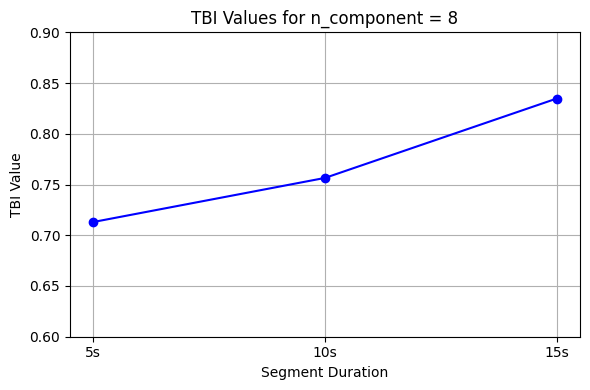

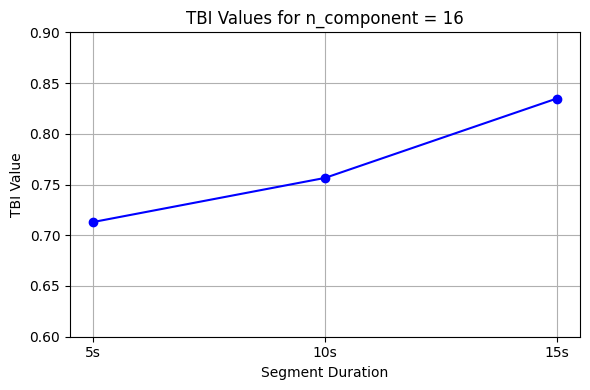

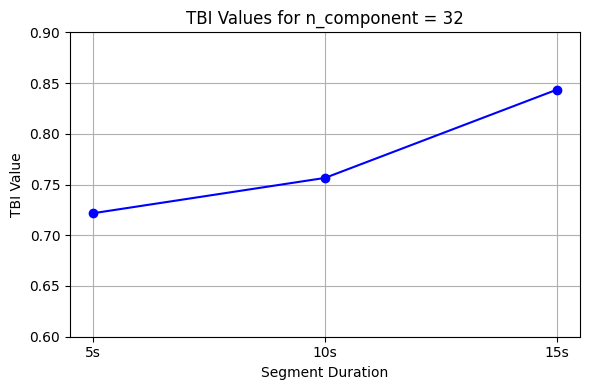

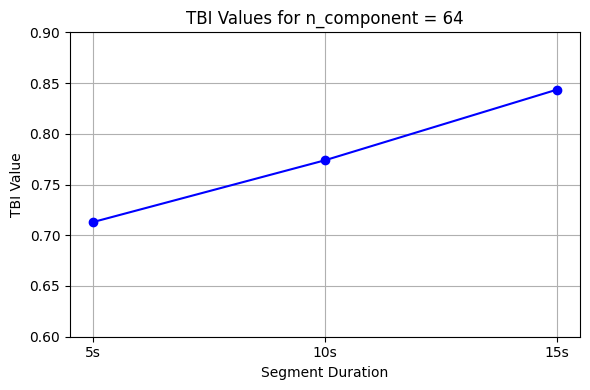

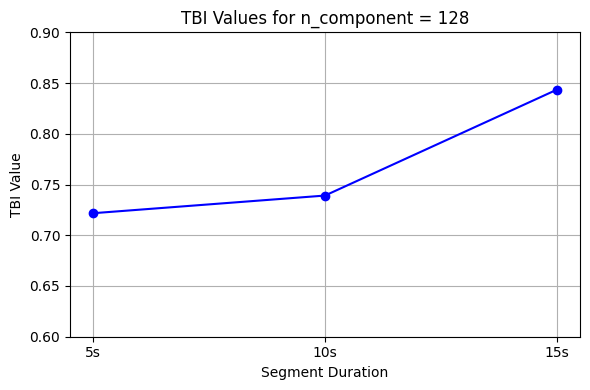

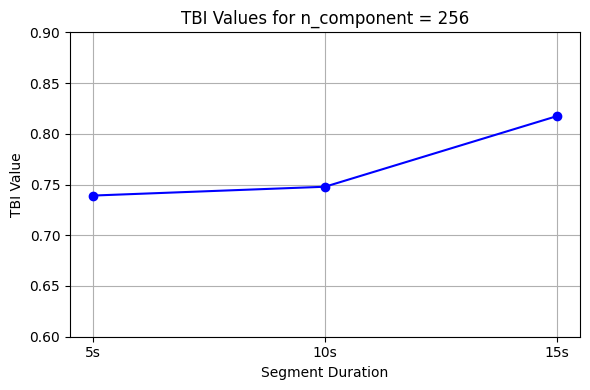

In [33]:
# Make sure to create a folder to store the plots
os.makedirs("TBI_Plots_By_Component", exist_ok=True)

# Extract unique components
components = sorted(set([entry['n_component'] for entry in TBI_results]))
segments = ['5s', '10s', '15s']

# Generate plot for each component
for component in components:
    segment_values = []
    tbi_values = []

    for seg in segments:
        for entry in TBI_results:
            if entry['n_component'] == component and entry['segment'] == seg:
                segment_values.append(seg)
                tbi_values.append(entry['TBI_value'])
    
    plt.figure(figsize=(6, 4))
    plt.plot(segment_values, tbi_values, marker='o', linestyle='-', color='blue')
    plt.title(f"TBI Values for n_component = {component}")
    plt.xlabel("Segment Duration")
    plt.ylabel("TBI Value")
    plt.ylim(0.6, 0.9)
    plt.grid(True)
    plt.tight_layout()
    
    # Save each figure
    filename = f"TBI_Plots_By_Component/TBI_n{component}.png"
    plt.savefig(filename, dpi=300)
    plt.show()
    plt.close()

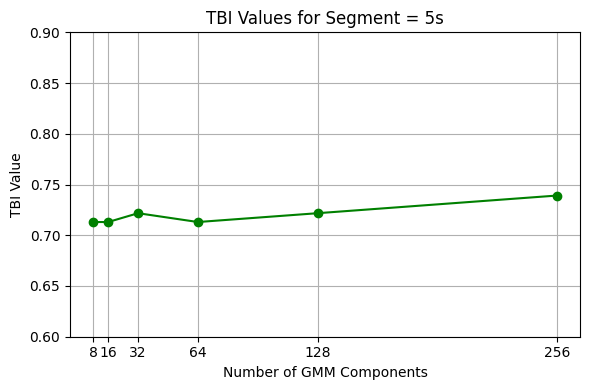

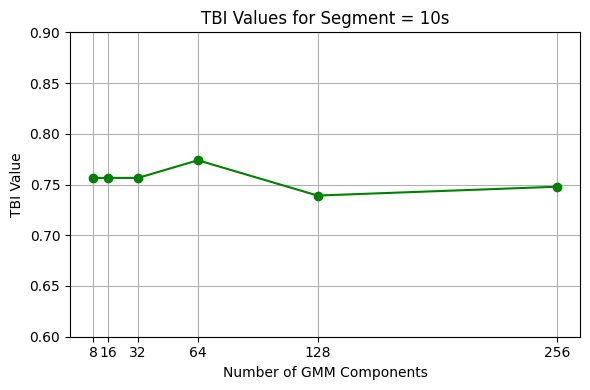

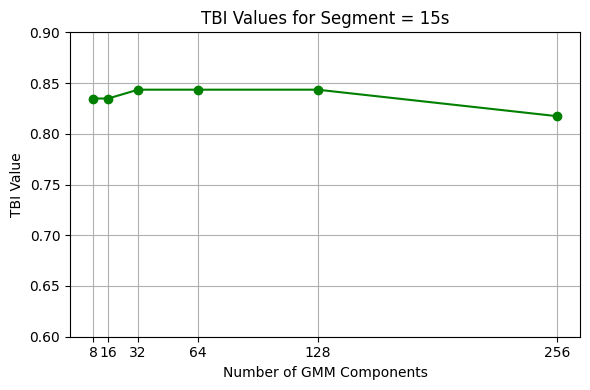

In [35]:
# Segments to plot
segments = ['5s', '10s', '15s']

os.makedirs("TBI_Plots_By_Segment", exist_ok=True)

# Plot for each segment
for seg in segments:
    component_values = []
    tbi_values = []
    
    for entry in TBI_results:
        if entry['segment'] == seg:
            component_values.append(entry['n_component'])
            tbi_values.append(entry['TBI_value'])
    
    plt.figure(figsize=(6, 4))
    plt.plot(component_values, tbi_values, marker='o', linestyle='-', color='green')
    plt.title(f"TBI Values for Segment = {seg}")
    plt.xlabel("Number of GMM Components")
    plt.ylabel("TBI Value")
    plt.xticks(component_values)
    plt.ylim(0.6, 0.9)
    plt.grid(True)
    plt.tight_layout()

    filename = f"TBI_Plots_By_Segment/TBI_segment_{seg}.png"
    plt.savefig(filename, dpi=300)
    plt.show()
    plt.close()

## Vérification du locuteur 

In [7]:
def evaluate_verification(gmm_dir, mfcc_dir):
    segs_list = ["5s", "10s", "15s"]
    n_components_list = [8, 16, 32, 64, 128, 256]

    speakers = os.listdir(mfcc_dir)  # Each folder is a speaker

    #dataframe that stores everything
    data = pd.DataFrame(columns=['n_component', 'seg', 'Identité Réel', 'Identité Proclamé', 'score'])
    
    for n_component in n_components_list:
        for seg in segs_list:
            for speaker in speakers:
                models = load_gmm_models(gmm_dir, n_component, speaker[0])    #get the models in the n_component with same gender
                
                test_path = os.path.join(mfcc_dir, speaker, "Test", seg)  # Only use Train folder
                for mfcc_file in os.listdir(test_path):
                    mfcc_path = os.path.join(test_path, mfcc_file)
                    mfcc_data = np.loadtxt(mfcc_path, delimiter=",")    #load the mfcc data

                    for speaker1, model in models.items():    # Loop through all the models 
                        log_likelihood = model.score(mfcc_data.T)  # Transpose MFCC to match GMM's expected input shape
                        new_row = pd.DataFrame([{'n_component': n_component, 'seg': seg, 'Identité Réel': speaker, 'Identité Proclamé':
                                                speaker1, 'score': log_likelihood}])
                        data = pd.concat([data, new_row], ignore_index=True)
                        
                        
    return data

In [ ]:
gmm_dir = r"C:\Users\wiame\Documents\1_SEMESTER_8\SYNTHESE VOCALE\PROJECT1\GMM"
mfcc_dir = r"C:\Users\wiame\Documents\1_SEMESTER_8\SYNTHESE VOCALE\PROJECT1\MFCC"
data = evaluate_verification(gmm_dir, mfcc_dir)
data

C:\Users\wiame\AppData\Local\Temp\ipykernel_21604\3545903157.py:24: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  data = pd.concat([data, new_row], ignore_index=True)


,n_component,seg,Identité Réel,Identité Proclamé,score
0,8,5s,F1,F1,-52.642297
1,8,5s,F1,F10,-56.439436
2,8,5s,F1,F11,-54.609795
3,8,5s,F1,F12,-52.506862
4,8,5s,F1,F13,-53.045764
...,...,...,...,...,...
24205,256,15s,H9,H5,-53.007996
24206,256,15s,H9,H6,-60.084872
24207,256,15s,H9,H7,-50.738770
24208,256,15s,H9,H8,-52.349620


In [11]:
data.to_csv(r"C:\Users\wiame\Documents\1_SEMESTER_8\SYNTHESE VOCALE\scores.txt", sep='\t', index=False)

In [15]:
min_value = data['score'].min()
max_value = data['score'].max()
int(min_value)-1, int(max_value)

(-136, -43)

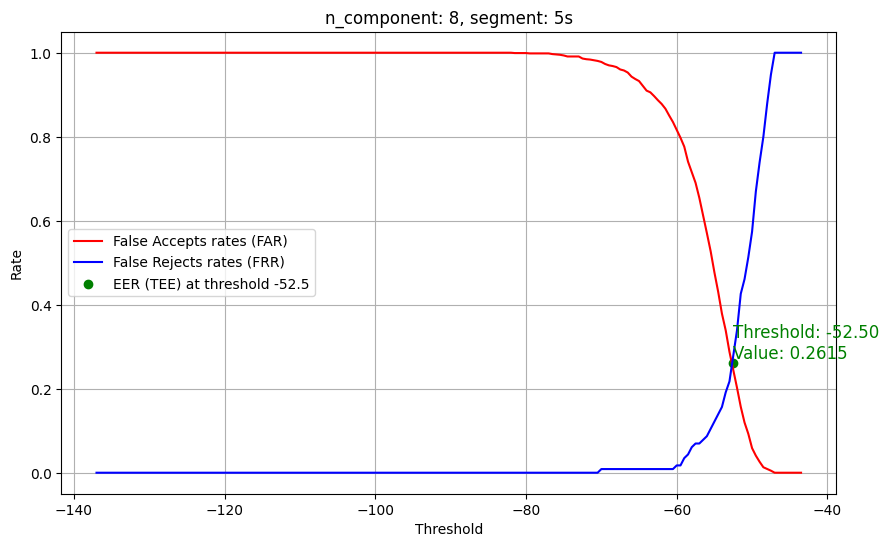

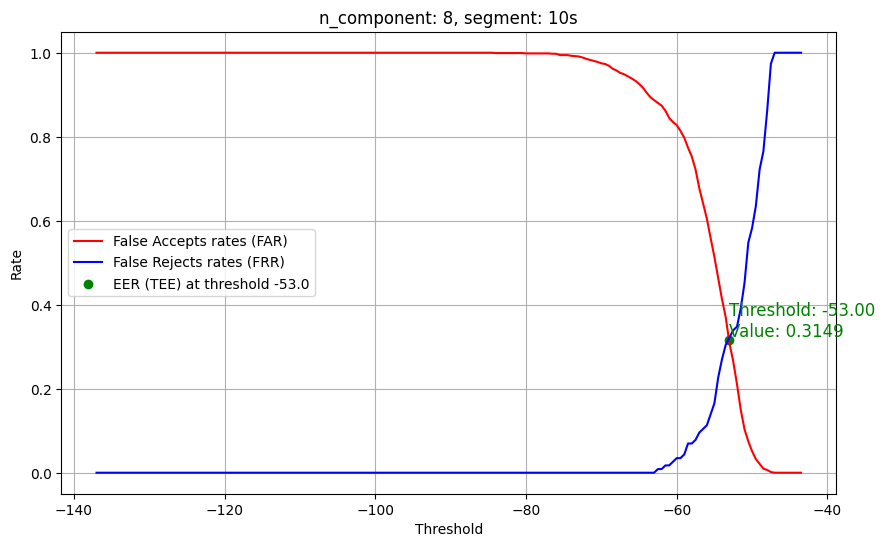

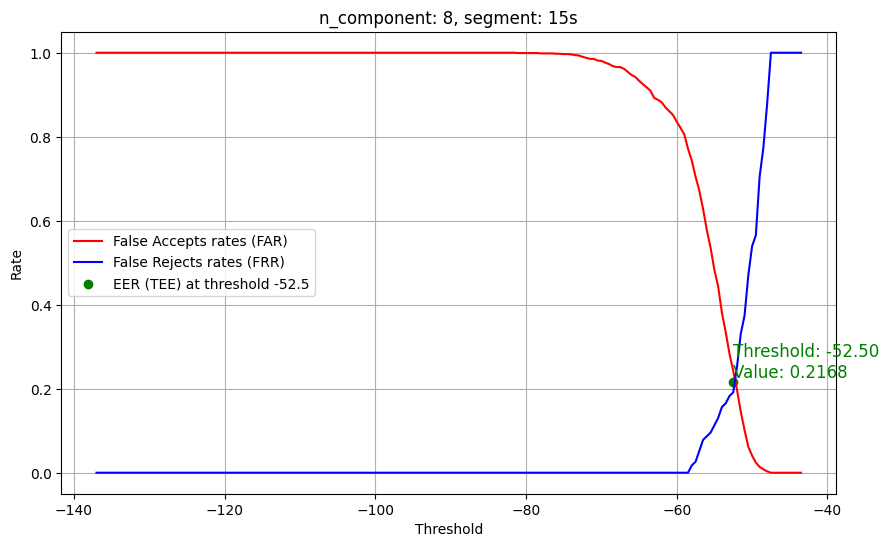

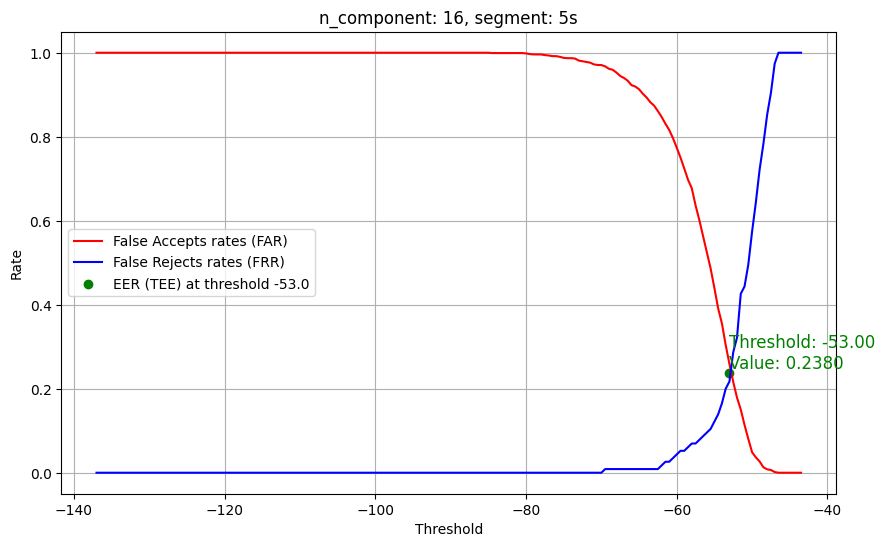

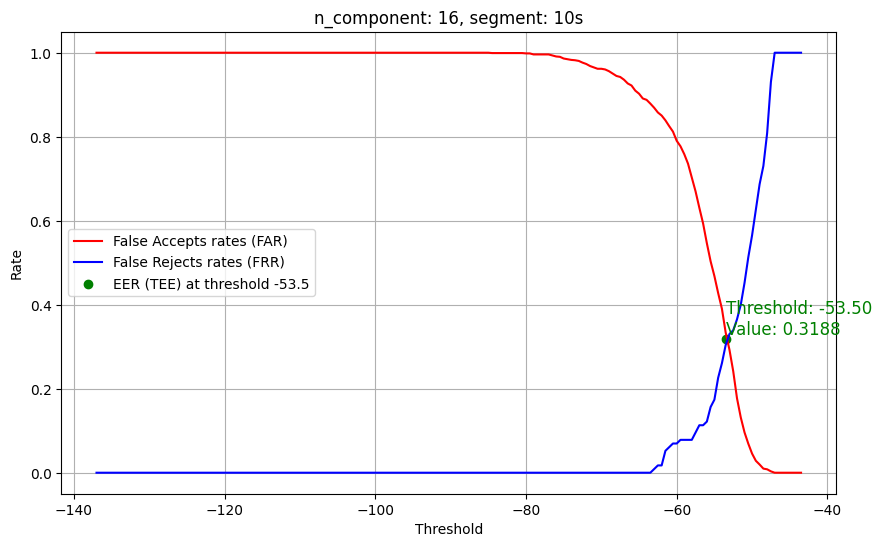

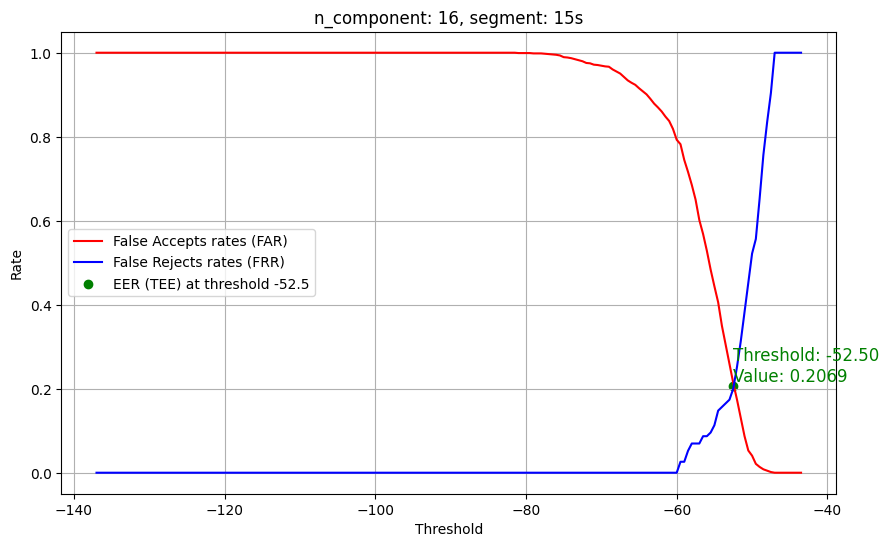

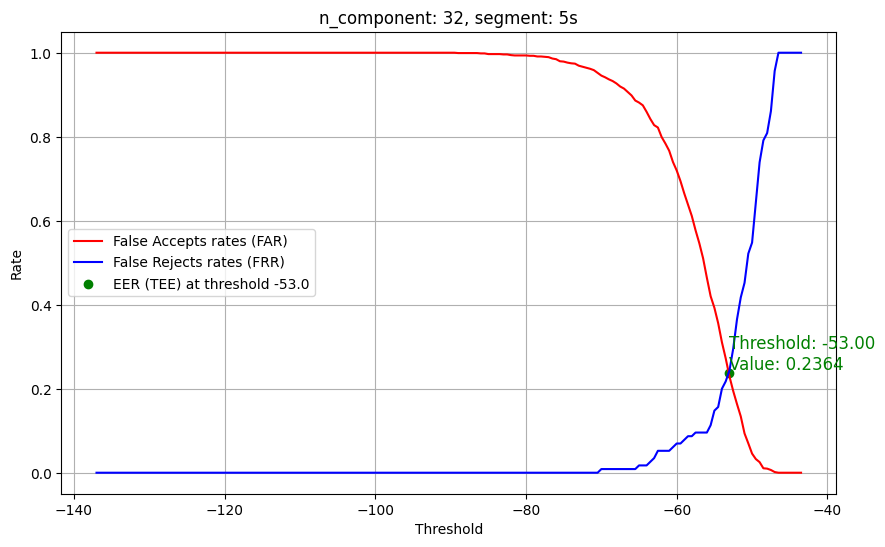

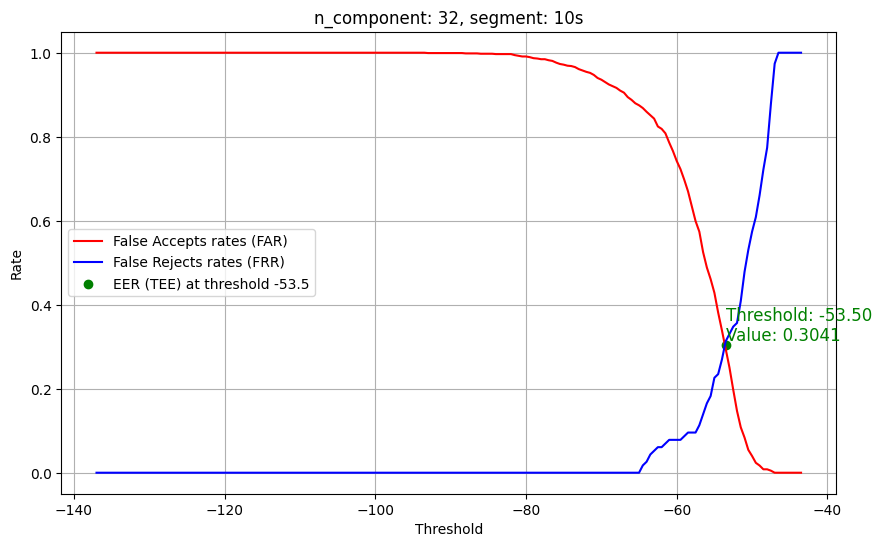

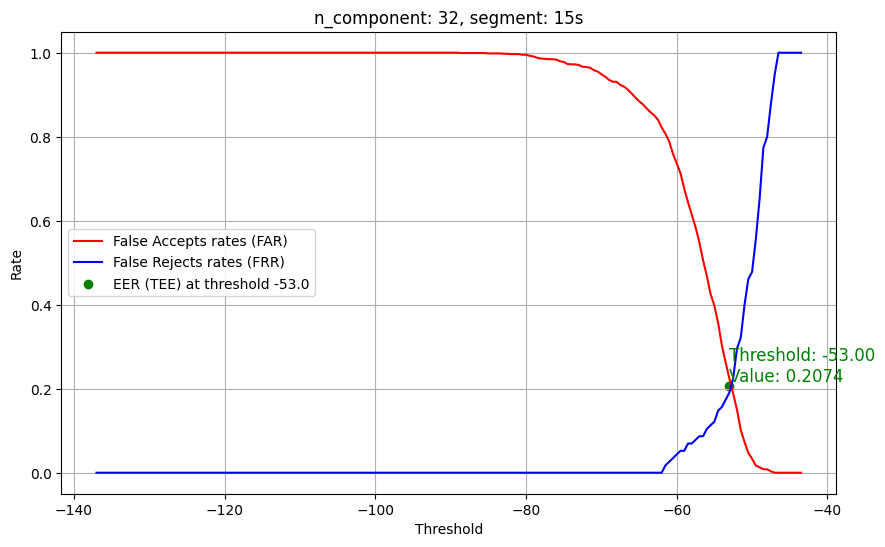

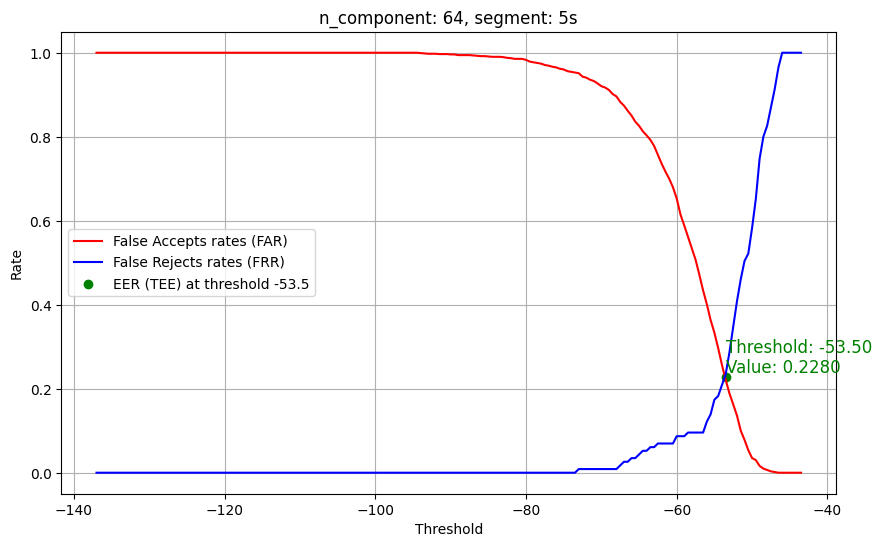

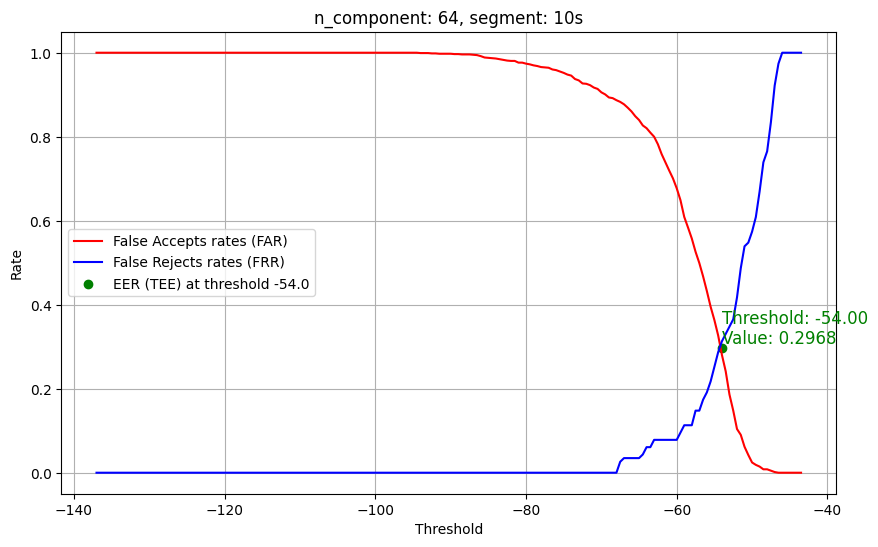

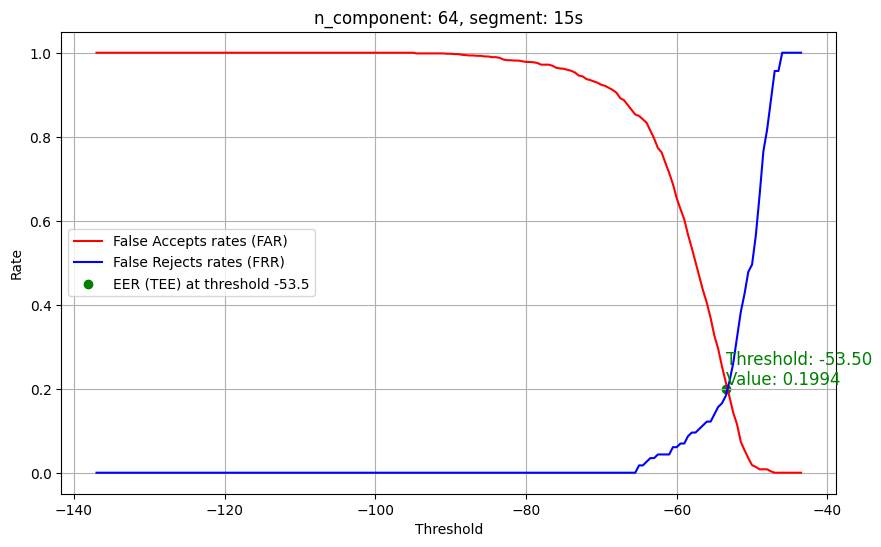

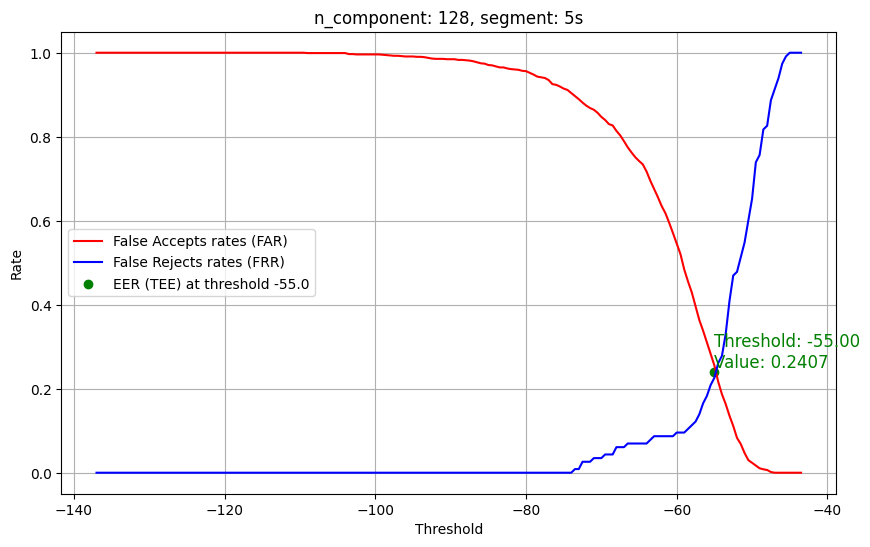

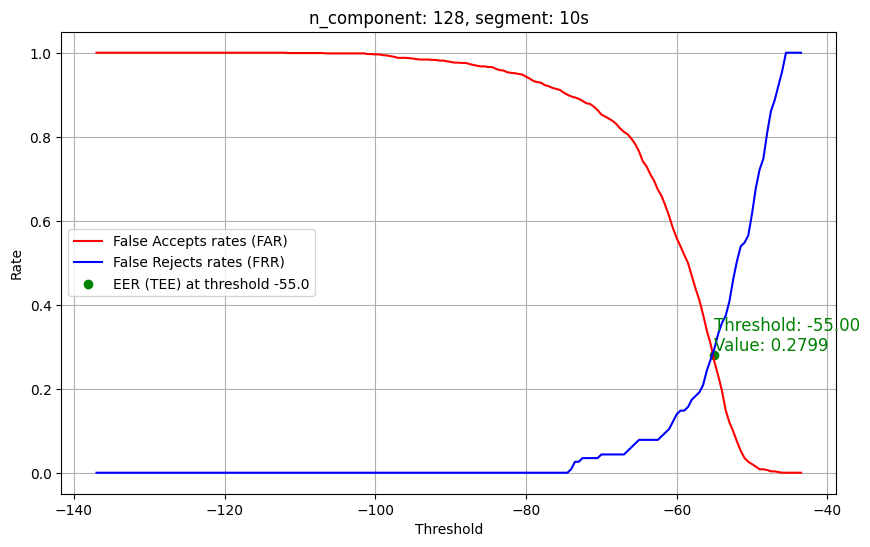

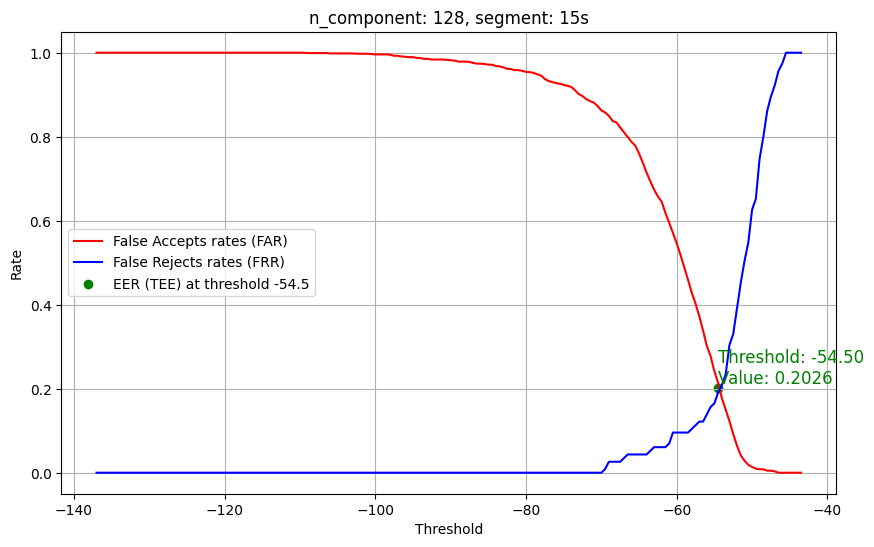

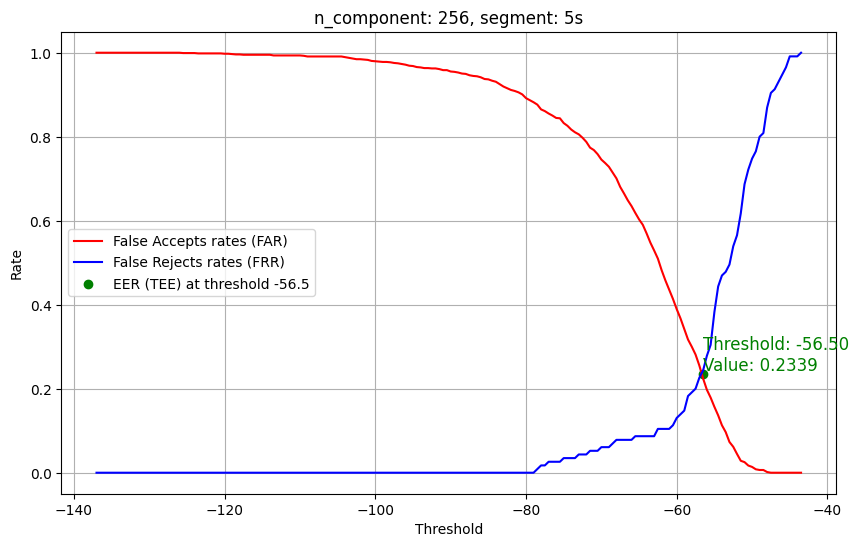

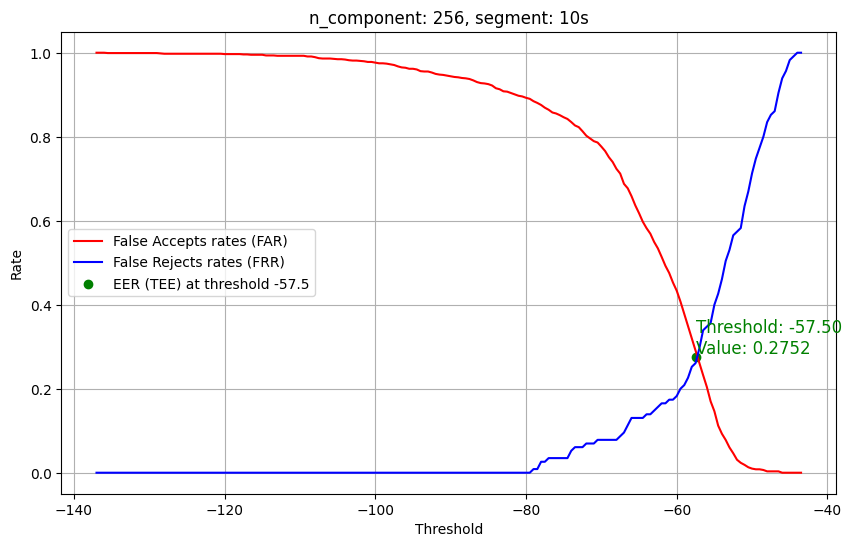

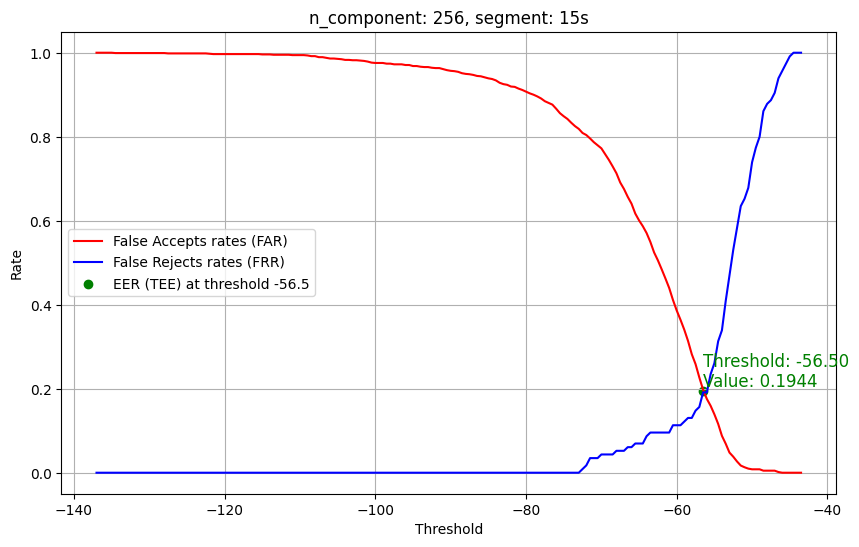

In [19]:

min_value = int(min_value) - 1
max_value = int(max_value)
n_components_list = [8, 16, 32, 64, 128, 256]
segs_list = ['5s', '10s', '15s']

EER_results = []

for n_component in n_components_list:
    for seg in segs_list:
        FAR_list = []
        FRR_list = []
        thresholds = []
        
        # Initialize variables to store the EER (TEE) threshold and value
        eer_threshold = None
        eer_value = None
        eer_difference = float('inf')  # Initialize with a very large value

        # Use numpy.arange for step size of 0.5
        for tresh in np.arange(min_value, max_value, 0.5):
            FA = 0
            FR = 0
            for index, row in data[(data['n_component'] == n_component) & (data['seg'] == seg)].iterrows():
                real_identity = row['Identité Réel']
                proclaimed_identity = row['Identité Proclamé']
                score = row['score']

                if (real_identity == proclaimed_identity) and (score < tresh):
                    FR += 1
                elif (real_identity != proclaimed_identity) and (score >= tresh):
                    FA += 1

            # Calculate total impostor trials and genuine trials
            total_impostor_trials = len(data[(data['n_component'] == n_component) & (data['seg'] == seg) & (data['Identité Réel'] != data['Identité Proclamé'])])  # Nombre d'imposteurs
            total_genuine_trials = len(data[(data['n_component'] == n_component) & (data['seg'] == seg) & (data['Identité Réel'] == data['Identité Proclamé'])])  # Nombre de vrais

            # Calculate FAR and FRR
            FAR = FA / total_impostor_trials
            FRR = FR / total_genuine_trials
            
            # Append FAR, FRR, and threshold to their respective lists
            FAR_list.append(FAR)
            FRR_list.append(FRR)
            thresholds.append(tresh)

            # Calculate the absolute difference between FAR and FRR
            diff = abs(FAR - FRR)

            # Update the EER if the current difference is smaller than the previous one
            if diff < eer_difference:
                eer_difference = diff
                eer_threshold = tresh
                eer_value = (FAR + FRR) / 2  # Equal Error Rate is the average of FAR and FRR at the threshold

        # Plotting the FAR and FRR curves
        plt.figure(figsize=(10, 6))
        plt.plot(thresholds, FAR_list, label='False Accepts rates (FAR)', color='red')
        plt.plot(thresholds, FRR_list, label='False Rejects rates (FRR)', color='blue')

        # Mark the EER (TEE) point on the plot
        plt.scatter(eer_threshold, eer_value, color='green', label=f'EER (TEE) at threshold {eer_threshold}')
        
        # Annotate the EER threshold and its corresponding value
        plt.text(eer_threshold, eer_value, f'Threshold: {eer_threshold:.2f}\nValue: {eer_value:.4f}', color='green', fontsize=12, ha='left', va='bottom')

        # Add labels and title
        plt.xlabel('Threshold')
        plt.ylabel('Rate')
        plt.title(f'n_component: {n_component}, segment: {seg}')
        plt.legend()
        plt.grid(True)

        # Save plot
        filename = f"plot_n{n_component}_seg{seg}_with_EER.png"
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        plt.show()

        # Close the plot to free memory
        plt.close()

        EER_results.append({
        "n_component": n_component,
        "segment": seg,
        "EER_threshold": eer_threshold,
        "EER_value": eer_value
        })


In [21]:
EER_results

[{'n_component': 8,
  'segment': '5s',
  'EER_threshold': -52.5,
  'EER_value': 0.26148815835984446},
 {'n_component': 8,
  'segment': '10s',
  'EER_threshold': -53.0,
  'EER_value': 0.31493460586779776},
 {'n_component': 8,
  'segment': '15s',
  'EER_threshold': -52.5,
  'EER_value': 0.21679038529515732},
 {'n_component': 16,
  'segment': '5s',
  'EER_threshold': -53.0,
  'EER_value': 0.23796394485683986},
 {'n_component': 16,
  'segment': '10s',
  'EER_threshold': -53.5,
  'EER_value': 0.3188405797101449},
 {'n_component': 16,
  'segment': '15s',
  'EER_threshold': -52.5,
  'EER_value': 0.20691056910569106},
 {'n_component': 32,
  'segment': '5s',
  'EER_threshold': -53.0,
  'EER_value': 0.23637327677624603},
 {'n_component': 32,
  'segment': '10s',
  'EER_threshold': -53.5,
  'EER_value': 0.3040827147401909},
 {'n_component': 32,
  'segment': '15s',
  'EER_threshold': -53.0,
  'EER_value': 0.20744079179922234},
 {'n_component': 64,
  'segment': '5s',
  'EER_threshold': -53.5,
  'EER

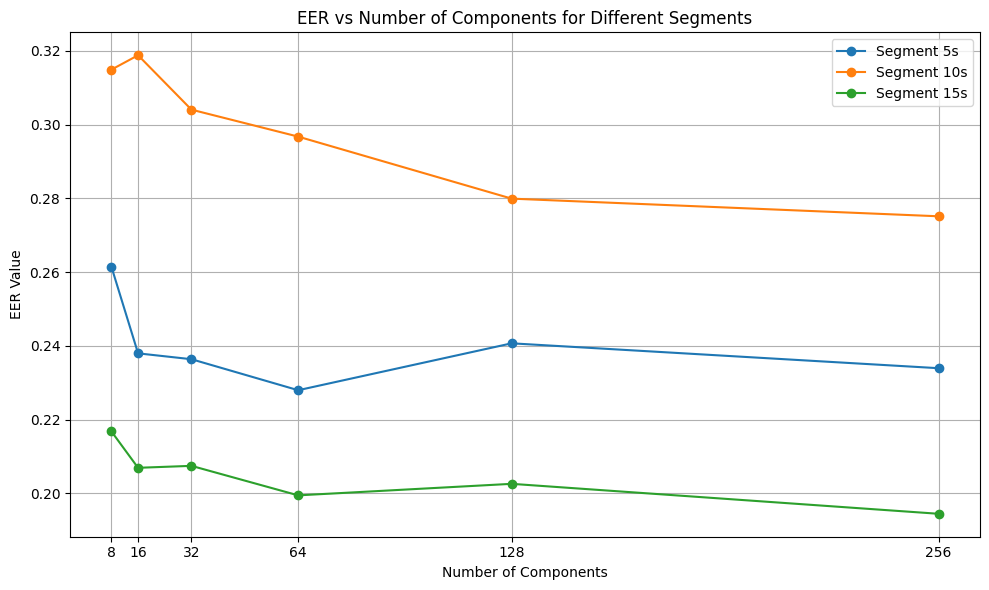

In [23]:
import matplotlib.pyplot as plt

# Prepare X values (components)
components = sorted(set(result['n_component'] for result in EER_results))
segments = ['5s', '10s', '15s']

# Create a dictionary to hold EER values by segment
eer_by_segment = {seg: [] for seg in segments}

# Fill in the EER values for each segment
for seg in segments:
    for comp in components:
        # Find the corresponding EER_value
        for result in EER_results:
            if result['segment'] == seg and result['n_component'] == comp:
                eer_by_segment[seg].append(result['EER_value'])
                break

# Plot
plt.figure(figsize=(10, 6))

for seg in segments:
    plt.plot(components, eer_by_segment[seg], marker='o', label=f'Segment {seg}')

plt.xlabel('Number of Components')
plt.ylabel('EER Value')
plt.title('EER vs Number of Components for Different Segments')
plt.xticks(components)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("general_EER_plot.png", dpi=300)
plt.show()
